# Task 3 — Neural Machine Translation

This notebook covers the required parts of Task 3:

- 70% train, 10% validation and 20% test data,
- word-based GRU translation in both directions,
- manual hyperparameter tuning,
- random versus Word2Vec embeddings,
- a character-based English → Spanish model,
- BLEU and chrF evaluation,
- a short sentence-length analysis.

Attention is intentionally not used here because it is introduced in Task 4.

## 1. Setup

A one-layer GRU encoder-decoder is used. GRUs are recurrent models with fewer parameters than LSTMs, which makes them suitable for CPU training. The baseline is deliberately simple so that the attention mechanism can be added clearly in Task 4.

In [2]:
from __future__ import annotations

import copy
import random
import re
import time
from collections import Counter
from functools import partial
from itertools import zip_longest
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from gensim.models import Word2Vec
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
from nltk.translate.chrf_score import corpus_chrf, sentence_chrf
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


SEED = 43
DEVICE = torch.device("cpu")

MAX_WORD_TOKENS = 50
MAX_CHARACTERS = 220
MAX_VOCAB_SIZE = 20000
MIN_WORD_FREQUENCY = 2

BATCH_SIZE = 96
EVALUATION_BATCH_SIZE = 128
FINAL_EPOCHS = 5
CHAR_EPOCHS = 3
PATIENCE = 2

TUNING_TRAIN_LIMIT = 15_000
TUNING_VALIDATION_LIMIT = 1_000
TUNING_EPOCHS = 2

EMBEDDING_TRAIN_LIMIT = 20_000
EMBEDDING_VALIDATION_LIMIT = 1_000
EMBEDDING_EPOCHS = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(8, torch.get_num_threads())))

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "preprocessed"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "task03"
PLOT_DIR = PROJECT_ROOT / "plots" / "task03"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

ENGLISH_PATH = DATA_DIR / "europarl_10pct_preprocessed.en"
SPANISH_PATH = DATA_DIR / "europarl_10pct_preprocessed.es"

if not ENGLISH_PATH.exists() or not SPANISH_PATH.exists():
    raise FileNotFoundError("Run Task 2 before this notebook.")

print("Device:", DEVICE)
print("English:", ENGLISH_PATH)
print("Spanish:", SPANISH_PATH)

Device: cpu
English: /home/theohagen/Desktop/nlp-machine-translation/data/preprocessed/europarl_10pct_preprocessed.en
Spanish: /home/theohagen/Desktop/nlp-machine-translation/data/preprocessed/europarl_10pct_preprocessed.es


## 2. Tokenization, data loading and split

The word tokenizer is identical to the tokenizer from Task 2. The length limits are applied before the split, so all final models use the same sentence pairs and exactly 20% of the retained data form the test set.

In [3]:
WORD_PATTERN = re.compile(
    r"\w+(?:['’]\w+)*|[^\w\s]",
    flags=re.UNICODE,
)


def word_tokenize(text):
    return WORD_PATTERN.findall(text)


def character_tokenize(text):
    return list(text)


def detokenize_words(tokens):
    text = " ".join(tokens)
    text = re.sub(r"\s+([.,!?;:%)])", r"\1", text)
    return re.sub(r"([¿¡(])\s+", r"\1", text)


def load_data():
    rows = []

    with ENGLISH_PATH.open("r", encoding="utf-8") as en_file,          SPANISH_PATH.open("r", encoding="utf-8") as es_file:

        for index, (english, spanish) in enumerate(
            tqdm(
                zip_longest(en_file, es_file, fillvalue=None),
                desc="Loading data",
            )
        ):
            if english is None or spanish is None:
                raise ValueError("The parallel files are not aligned.")

            english = english.rstrip("\r\n")
            spanish = spanish.rstrip("\r\n")

            en_words = len(word_tokenize(english))
            es_words = len(word_tokenize(spanish))

            if (
                0 < en_words <= MAX_WORD_TOKENS
                and 0 < es_words <= MAX_WORD_TOKENS
                and len(english) <= MAX_CHARACTERS
                and len(spanish) <= MAX_CHARACTERS
            ):
                rows.append((index, english, spanish))

    return pd.DataFrame(
        rows,
        columns=["original_index", "english", "spanish"],
    )


data = load_data()

indices = np.random.default_rng(SEED).permutation(len(data))
n_test = int(0.20 * len(data))
n_validation = int(0.10 * len(data))

splits = {
    "test": data.iloc[indices[:n_test]].reset_index(drop=True),
    "validation": data.iloc[
        indices[n_test:n_test + n_validation]
    ].reset_index(drop=True),
    "train": data.iloc[
        indices[n_test + n_validation:]
    ].reset_index(drop=True),
}

pd.DataFrame(
    {
        "split": list(splits),
        "pairs": [len(splits[name]) for name in splits],
        "percentage": [
            100 * len(splits[name]) / len(data)
            for name in splits
        ],
    }
)

Loading data: 196095it [00:01, 120424.12it/s]


,split,pairs,percentage
0,test,29995,19.999867
1,validation,14997,9.999600
2,train,104984,70.000533


## 3. Vocabulary and batches

In [4]:
PAD, UNK, BOS, EOS = "<pad>", "<unk>", "<bos>", "<eos>"
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3


class Vocabulary:
    def __init__(self, texts, tokenizer, max_size=None, min_frequency=1):
        counts = Counter(
            token
            for text in tqdm(texts, desc="Vocabulary")
            for token in tokenizer(text)
        )

        tokens = [
            token
            for token, frequency in counts.most_common()
            if frequency >= min_frequency
        ]

        if max_size is not None:
            tokens = tokens[:max_size - 4]

        self.itos = [PAD, UNK, BOS, EOS, *tokens]
        self.stoi = {
            token: index
            for index, token in enumerate(self.itos)
        }

    def __len__(self):
        return len(self.itos)

    def encode(self, tokens):
        return [
            BOS_ID,
            *[self.stoi.get(token, UNK_ID) for token in tokens],
            EOS_ID,
        ]

    def decode(self, indices):
        tokens = []
        for index in indices:
            if index == EOS_ID:
                break
            if index not in {PAD_ID, BOS_ID}:
                tokens.append(self.itos[index])
        return tokens


class TranslationDataset(Dataset):
    def __init__(self, frame, source_column, target_column):
        self.sources = frame[source_column].tolist()
        self.targets = frame[target_column].tolist()
        self.indices = frame["original_index"].tolist()

    def __len__(self):
        return len(self.sources)

    def __getitem__(self, index):
        return (
            self.sources[index],
            self.targets[index],
            self.indices[index],
        )


def collate_batch(batch, source_vocab, target_vocab, tokenizer):
    sources, targets, indices = zip(*batch)

    source_sequences = [
        torch.tensor(
            source_vocab.encode(tokenizer(text)),
            dtype=torch.long,
        )
        for text in sources
    ]
    target_sequences = [
        torch.tensor(
            target_vocab.encode(tokenizer(text)),
            dtype=torch.long,
        )
        for text in targets
    ]

    return {
        "source": pad_sequence(
            source_sequences,
            batch_first=True,
            padding_value=PAD_ID,
        ),
        "source_lengths": torch.tensor(
            [len(sequence) for sequence in source_sequences]
        ),
        "target": pad_sequence(
            target_sequences,
            batch_first=True,
            padding_value=PAD_ID,
        ),
        "source_text": list(sources),
        "target_text": list(targets),
        "original_index": list(indices),
    }


def make_loader(
    frame,
    source_column,
    target_column,
    source_vocab,
    target_vocab,
    tokenizer,
    batch_size,
    shuffle,
):
    return DataLoader(
        TranslationDataset(frame, source_column, target_column),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        collate_fn=partial(
            collate_batch,
            source_vocab=source_vocab,
            target_vocab=target_vocab,
            tokenizer=tokenizer,
        ),
    )

In [5]:
english_word_vocab = Vocabulary(
    splits["train"]["english"],
    word_tokenize,
    MAX_VOCAB_SIZE,
    MIN_WORD_FREQUENCY,
)

spanish_word_vocab = Vocabulary(
    splits["train"]["spanish"],
    word_tokenize,
    MAX_VOCAB_SIZE,
    MIN_WORD_FREQUENCY,
)

print("English vocabulary:", len(english_word_vocab))
print("Spanish vocabulary:", len(spanish_word_vocab))

Vocabulary: 100%|██████████| 104984/104984 [00:00<00:00, 215150.42it/s]

English vocabulary: 18353
Spanish vocabulary: 20000


## 4. GRU sequence-to-sequence model

The encoder converts the source sentence into its final hidden state. The decoder uses this state to generate the target sentence. During training, the correct target prefix is supplied to the decoder. During inference, greedy decoding is used.

In [6]:
class Seq2SeqGRU(nn.Module):
    def __init__(
        self,
        source_vocab_size,
        target_vocab_size,
        embedding_dim,
        hidden_size,
        dropout,
        source_embeddings=None,
        target_embeddings=None,
    ):
        super().__init__()

        self.source_embedding = nn.Embedding(
            source_vocab_size,
            embedding_dim,
            padding_idx=PAD_ID,
        )
        self.target_embedding = nn.Embedding(
            target_vocab_size,
            embedding_dim,
            padding_idx=PAD_ID,
        )
        self.dropout = nn.Dropout(dropout)
        self.encoder = nn.GRU(
            embedding_dim,
            hidden_size,
            batch_first=True,
        )
        self.decoder = nn.GRU(
            embedding_dim,
            hidden_size,
            batch_first=True,
        )
        self.output = nn.Linear(hidden_size, target_vocab_size)

        if source_embeddings is not None:
            self.source_embedding.weight.data.copy_(
                torch.tensor(source_embeddings)
            )
        if target_embeddings is not None:
            self.target_embedding.weight.data.copy_(
                torch.tensor(target_embeddings)
            )

    def encode(self, source, source_lengths):
        embedded = self.dropout(self.source_embedding(source))
        packed = pack_padded_sequence(
            embedded,
            source_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.encoder(packed)
        return hidden

    def decode(self, target_input, hidden):
        embedded = self.dropout(self.target_embedding(target_input))
        output, hidden = self.decoder(embedded, hidden)
        return self.output(output), hidden

    def forward(self, source, source_lengths, target_input):
        hidden = self.encode(source, source_lengths)
        logits, _ = self.decode(target_input, hidden)
        return logits


def build_model(
    source_vocab,
    target_vocab,
    config,
    source_embeddings=None,
    target_embeddings=None,
):
    return Seq2SeqGRU(
        len(source_vocab),
        len(target_vocab),
        config["embedding_dim"],
        config["hidden_size"],
        config["dropout"],
        source_embeddings,
        target_embeddings,
    ).to(DEVICE)

## 5. Training and evaluation

In [7]:
def loss_epoch(model, loader, criterion, optimizer=None):
    model.train(optimizer is not None)
    total_loss = 0.0
    total_tokens = 0

    for batch in tqdm(loader, leave=False):
        source = batch["source"].to(DEVICE)
        lengths = batch["source_lengths"]
        target = batch["target"].to(DEVICE)

        if optimizer is not None:
            optimizer.zero_grad()

        with torch.set_grad_enabled(optimizer is not None):
            logits = model(source, lengths, target[:, :-1])
            expected = target[:, 1:]

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                expected.reshape(-1),
            )

            if optimizer is not None:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    1.0,
                )
                optimizer.step()

        token_count = expected.ne(PAD_ID).sum().item()
        total_loss += loss.item() * token_count
        total_tokens += token_count

    return total_loss / total_tokens


def fit(model, train_loader, validation_loader, config, epochs):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
    )

    best_state = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    waiting = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss = loss_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )
        validation_loss = loss_epoch(
            model,
            validation_loader,
            criterion,
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "validation_loss": validation_loss,
            }
        )

        print(
            f"epoch={epoch} "
            f"train_loss={train_loss:.4f} "
            f"validation_loss={validation_loss:.4f}"
        )

        if validation_loss < best_loss:
            best_loss = validation_loss
            best_state = copy.deepcopy(model.state_dict())
            waiting = 0
        else:
            waiting += 1

        if waiting >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return pd.DataFrame(history), best_loss

In [8]:
@torch.no_grad()
def translate_batch(model, source, lengths, target_vocab, max_length):
    hidden = model.encode(source, lengths)
    current = torch.full(
        (source.size(0), 1),
        BOS_ID,
        dtype=torch.long,
        device=DEVICE,
    )

    predictions = [[] for _ in range(source.size(0))]
    finished = torch.zeros(
        source.size(0),
        dtype=torch.bool,
        device=DEVICE,
    )

    for _ in range(max_length):
        logits, hidden = model.decode(current, hidden)
        current = logits[:, -1].argmax(-1, keepdim=True)

        for row, token in enumerate(current.squeeze(1).tolist()):
            if not finished[row]:
                if token == EOS_ID:
                    finished[row] = True
                else:
                    predictions[row].append(token)

        if finished.all():
            break

    return [target_vocab.decode(ids) for ids in predictions]


def corpus_metrics(references, hypotheses):
    bleu = 100 * corpus_bleu(
        [[word_tokenize(reference)] for reference in references],
        [word_tokenize(hypothesis) for hypothesis in hypotheses],
        smoothing_function=SmoothingFunction().method1,
    )

    chrf = 100 * corpus_chrf(
        [[reference] for reference in references],
        hypotheses,
    )

    return bleu, chrf


@torch.no_grad()
def evaluate(model, loader, target_vocab, detokenizer, max_length):
    rows = []
    model.eval()

    for batch in tqdm(loader, desc="Translating", leave=False):
        token_predictions = translate_batch(
            model,
            batch["source"].to(DEVICE),
            batch["source_lengths"],
            target_vocab,
            max_length,
        )

        hypotheses = [
            detokenizer(tokens)
            for tokens in token_predictions
        ]

        for source, reference, hypothesis, index in zip(
            batch["source_text"],
            batch["target_text"],
            hypotheses,
            batch["original_index"],
        ):
            rows.append(
                {
                    "original_index": index,
                    "source": source,
                    "reference": reference,
                    "hypothesis": hypothesis,
                    "source_length": len(word_tokenize(source)),
                    "sentence_chrf": 100 * sentence_chrf(
                        reference,
                        hypothesis,
                    ),
                }
            )

    predictions = pd.DataFrame(rows)
    bleu, chrf = corpus_metrics(
        predictions["reference"].tolist(),
        predictions["hypothesis"].tolist(),
    )

    return bleu, chrf, predictions

In [9]:
def run_experiment(
    train_frame,
    validation_frame,
    source_column,
    target_column,
    source_vocab,
    target_vocab,
    tokenizer,
    detokenizer,
    config,
    epochs,
    max_length,
    source_embeddings=None,
    target_embeddings=None,
    test_frame=None,
    save_name=None,
):
    train_loader = make_loader(
        train_frame,
        source_column,
        target_column,
        source_vocab,
        target_vocab,
        tokenizer,
        BATCH_SIZE,
        True,
    )
    validation_loader = make_loader(
        validation_frame,
        source_column,
        target_column,
        source_vocab,
        target_vocab,
        tokenizer,
        EVALUATION_BATCH_SIZE,
        False,
    )

    model = build_model(
        source_vocab,
        target_vocab,
        config,
        source_embeddings,
        target_embeddings,
    )

    start = time.perf_counter()
    history, validation_loss = fit(
        model,
        train_loader,
        validation_loader,
        config,
        epochs,
    )
    validation_bleu, validation_chrf, _ = evaluate(
        model,
        validation_loader,
        target_vocab,
        detokenizer,
        max_length,
    )

    result = {
        "model": model,
        "history": history,
        "validation_loss": validation_loss,
        "validation_bleu": validation_bleu,
        "validation_chrf": validation_chrf,
        "parameters": sum(
            parameter.numel()
            for parameter in model.parameters()
        ),
    }

    if test_frame is not None:
        test_loader = make_loader(
            test_frame,
            source_column,
            target_column,
            source_vocab,
            target_vocab,
            tokenizer,
            EVALUATION_BATCH_SIZE,
            False,
        )
        test_bleu, test_chrf, predictions = evaluate(
            model,
            test_loader,
            target_vocab,
            detokenizer,
            max_length,
        )
        result.update(
            {
                "test_bleu": test_bleu,
                "test_chrf": test_chrf,
                "predictions": predictions,
            }
        )

    result["seconds"] = time.perf_counter() - start

    if save_name is not None:
        history.to_csv(
            ARTIFACT_DIR / f"{save_name}_history.csv",
            index=False,
        )
        result["predictions"].to_csv(
            ARTIFACT_DIR / f"{save_name}_predictions.csv",
            index=False,
        )
        torch.save(
            {
                "state_dict": model.state_dict(),
                "config": config,
                "source_vocab": source_vocab.stoi,
                "target_vocab": target_vocab.stoi,
            },
            ARTIFACT_DIR / f"{save_name}.pt",
        )

    return result

## 6. Manual hyperparameter tuning

The candidates below compare learning rates and model size on the same subsets.

In [10]:
TUNING_CONFIGS = {
    "compact_lr_0005": {
        "embedding_dim": 128,
        "hidden_size": 192,
        "dropout": 0.20,
        "learning_rate": 0.0005,
    },
    "compact_lr_001": {
        "embedding_dim": 128,
        "hidden_size": 192,
        "dropout": 0.20,
        "learning_rate": 0.001,
    },
    "larger_lr_001": {
        "embedding_dim": 160,
        "hidden_size": 256,
        "dropout": 0.25,
        "learning_rate": 0.001,
    },
}

In [11]:
tuning_rows = []

for name, config in TUNING_CONFIGS.items():
    print("\n", name)

    result = run_experiment(
        splits["train"].iloc[:TUNING_TRAIN_LIMIT],
        splits["validation"].iloc[:TUNING_VALIDATION_LIMIT],
        "english",
        "spanish",
        english_word_vocab,
        spanish_word_vocab,
        word_tokenize,
        detokenize_words,
        config,
        TUNING_EPOCHS,
        MAX_WORD_TOKENS + 10,
    )

    tuning_rows.append(
        {
            "name": name,
            **config,
            "validation_loss": result["validation_loss"],
            "validation_bleu": result["validation_bleu"],
            "validation_chrf": result["validation_chrf"],
            "parameters": result["parameters"],
            "seconds": result["seconds"],
        }
    )

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["validation_chrf", "validation_bleu"],
    ascending=False,
)

tuning_results.to_csv(
    ARTIFACT_DIR / "hyperparameter_tuning.csv",
    index=False,
)

tuning_results


 compact_lr_0005


epoch=1 train_loss=6.7153 validation_loss=5.8287


epoch=2 train_loss=5.6257 validation_loss=5.4120



 compact_lr_001


epoch=1 train_loss=6.3431 validation_loss=5.5328


epoch=2 train_loss=5.2929 validation_loss=5.0751



 larger_lr_001


epoch=1 train_loss=6.1865 validation_loss=5.3592


epoch=2 train_loss=5.1171 validation_loss=4.9113


,name,embedding_dim,hidden_size,dropout,learning_rate,validation_loss,validation_bleu,validation_chrf,parameters,seconds
2,larger_lr_001,160,256,0.25,0.0010,4.911324,1.870350,17.294734,11918528,158.211422
1,compact_lr_001,128,192,0.20,0.0010,5.075115,1.133792,16.122476,9140128,132.720206
0,compact_lr_0005,128,192,0.20,0.0005,5.412021,1.324415,15.368370,9140128,135.281543


In [12]:
FINAL_CONFIG_NAME = "compact_lr_001"
FINAL_CONFIG = TUNING_CONFIGS[FINAL_CONFIG_NAME]

FINAL_CONFIG

{'embedding_dim': 128,
 'hidden_size': 192,
 'dropout': 0.2,
 'learning_rate': 0.001}

## 7. Random versus Word2Vec embeddings

In [13]:
class TokenizedSentences:
    def __init__(self, texts):
        self.texts = texts

    def __iter__(self):
        for text in self.texts:
            yield word_tokenize(text)


def train_word2vec(texts):
    return Word2Vec(
        TokenizedSentences(texts),
        vector_size=FINAL_CONFIG["embedding_dim"],
        window=5,
        min_count=1,
        workers=max(1, min(4, torch.get_num_threads())),
        epochs=3,
        seed=SEED,
    )


def embedding_matrix(vocab, word2vec):
    matrix = np.random.default_rng(SEED).normal(
        0,
        0.1,
        (len(vocab), FINAL_CONFIG["embedding_dim"]),
    ).astype(np.float32)

    matrix[PAD_ID] = 0

    for token, index in vocab.stoi.items():
        if token in word2vec.wv:
            matrix[index] = word2vec.wv[token]

    return matrix


english_word2vec = train_word2vec(
    splits["train"]["english"]
)
spanish_word2vec = train_word2vec(
    splits["train"]["spanish"]
)

english_word2vec_matrix = embedding_matrix(
    english_word_vocab,
    english_word2vec,
)
spanish_word2vec_matrix = embedding_matrix(
    spanish_word_vocab,
    spanish_word2vec,
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [14]:
embedding_rows = []

embedding_options = {
    "random": (None, None),
    "word2vec": (
        english_word2vec_matrix,
        spanish_word2vec_matrix,
    ),
}

for name, matrices in embedding_options.items():
    print("\n", name)

    result = run_experiment(
        splits["train"].iloc[:EMBEDDING_TRAIN_LIMIT],
        splits["validation"].iloc[:EMBEDDING_VALIDATION_LIMIT],
        "english",
        "spanish",
        english_word_vocab,
        spanish_word_vocab,
        word_tokenize,
        detokenize_words,
        FINAL_CONFIG,
        EMBEDDING_EPOCHS,
        MAX_WORD_TOKENS + 10,
        matrices[0],
        matrices[1],
    )

    embedding_rows.append(
        {
            "embedding": name,
            "validation_loss": result["validation_loss"],
            "validation_bleu": result["validation_bleu"],
            "validation_chrf": result["validation_chrf"],
            "seconds": result["seconds"],
        }
    )

embedding_results = pd.DataFrame(embedding_rows).sort_values(
    ["validation_chrf", "validation_bleu"],
    ascending=False,
)

embedding_results.to_csv(
    ARTIFACT_DIR / "embedding_comparison.csv",
    index=False,
)

embedding_results


 random


epoch=1 train_loss=6.1284 validation_loss=5.3369


epoch=2 train_loss=5.1231 validation_loss=4.8971



 word2vec


epoch=1 train_loss=6.0467 validation_loss=5.1980


epoch=2 train_loss=4.9191 validation_loss=4.6546


,embedding,validation_loss,validation_bleu,validation_chrf,seconds
0,random,4.897100,1.884994,17.467386,177.628894
1,word2vec,4.654623,1.920660,15.433703,183.536456


In [15]:
FINAL_EMBEDDING = "word2vec"

if FINAL_EMBEDDING == "word2vec":
    EN_EMBEDDINGS = english_word2vec_matrix
    ES_EMBEDDINGS = spanish_word2vec_matrix
elif FINAL_EMBEDDING == "random":
    EN_EMBEDDINGS = None
    ES_EMBEDDINGS = None
else:
    raise ValueError("Use 'random' or 'word2vec'.")

## 8. Final word models

In [16]:
word_en_to_es = run_experiment(
    splits["train"],
    splits["validation"],
    "english",
    "spanish",
    english_word_vocab,
    spanish_word_vocab,
    word_tokenize,
    detokenize_words,
    FINAL_CONFIG,
    FINAL_EPOCHS,
    MAX_WORD_TOKENS + 10,
    EN_EMBEDDINGS,
    ES_EMBEDDINGS,
    splits["test"],
    "word_en_to_es",
)

word_es_to_en = run_experiment(
    splits["train"],
    splits["validation"],
    "spanish",
    "english",
    spanish_word_vocab,
    english_word_vocab,
    word_tokenize,
    detokenize_words,
    FINAL_CONFIG,
    FINAL_EPOCHS,
    MAX_WORD_TOKENS + 10,
    ES_EMBEDDINGS,
    EN_EMBEDDINGS,
    splits["test"],
    "word_es_to_en",
)

epoch=1 train_loss=4.7561 validation_loss=4.0230


epoch=2 train_loss=3.8480 validation_loss=3.6726


epoch=3 train_loss=3.5443 validation_loss=3.5015


epoch=4 train_loss=3.3509 validation_loss=3.3982


epoch=5 train_loss=3.2083 validation_loss=3.3319


epoch=1 train_loss=4.8012 validation_loss=4.1222


epoch=2 train_loss=3.9551 validation_loss=3.7866


epoch=3 train_loss=3.6598 validation_loss=3.6141


epoch=4 train_loss=3.4629 validation_loss=3.5050


epoch=5 train_loss=3.3184 validation_loss=3.4321


## 9. Character-based model

In [17]:
english_character_vocab = Vocabulary(
    splits["train"]["english"],
    character_tokenize,
)
spanish_character_vocab = Vocabulary(
    splits["train"]["spanish"],
    character_tokenize,
)

CHAR_CONFIG = {
    "embedding_dim": 32,
    "hidden_size": 128,
    "dropout": 0.20,
    "learning_rate": 0.001,
}

character_en_to_es = run_experiment(
    splits["train"],
    splits["validation"],
    "english",
    "spanish",
    english_character_vocab,
    spanish_character_vocab,
    character_tokenize,
    lambda tokens: "".join(tokens),
    CHAR_CONFIG,
    CHAR_EPOCHS,
    MAX_CHARACTERS + 20,
    None,
    None,
    splits["test"],
    "character_en_to_es",
)

Vocabulary: 100%|██████████| 104984/104984 [00:00<00:00, 291234.82it/s]


epoch=1 train_loss=1.9502 validation_loss=1.5026


epoch=2 train_loss=1.4575 validation_loss=1.3200


epoch=3 train_loss=1.3490 validation_loss=1.2499


## 10. Results

In [18]:
final_results = pd.DataFrame(
    [
        {
            "model": "word",
            "direction": "English → Spanish",
            "embedding": FINAL_EMBEDDING,
            "validation_bleu": word_en_to_es["validation_bleu"],
            "validation_chrf": word_en_to_es["validation_chrf"],
            "test_bleu": word_en_to_es["test_bleu"],
            "test_chrf": word_en_to_es["test_chrf"],
            "parameters": word_en_to_es["parameters"],
            "seconds": word_en_to_es["seconds"],
        },
        {
            "model": "word",
            "direction": "Spanish → English",
            "embedding": FINAL_EMBEDDING,
            "validation_bleu": word_es_to_en["validation_bleu"],
            "validation_chrf": word_es_to_en["validation_chrf"],
            "test_bleu": word_es_to_en["test_bleu"],
            "test_chrf": word_es_to_en["test_chrf"],
            "parameters": word_es_to_en["parameters"],
            "seconds": word_es_to_en["seconds"],
        },
        {
            "model": "character",
            "direction": "English → Spanish",
            "embedding": "character",
            "validation_bleu": character_en_to_es["validation_bleu"],
            "validation_chrf": character_en_to_es["validation_chrf"],
            "test_bleu": character_en_to_es["test_bleu"],
            "test_chrf": character_en_to_es["test_chrf"],
            "parameters": character_en_to_es["parameters"],
            "seconds": character_en_to_es["seconds"],
        },
    ]
)

final_results.to_csv(
    ARTIFACT_DIR / "final_results.csv",
    index=False,
)

final_results

,model,direction,embedding,validation_bleu,validation_chrf,test_bleu,test_chrf,parameters,seconds
0,word,English → Spanish,word2vec,5.954052,27.917986,5.996151,27.974169,9140128,2594.176484
1,word,Spanish → English,word2vec,6.249660,29.269733,6.234062,29.237274,8822257,2481.192636
2,character,English → Spanish,character,1.209565,19.451151,1.227893,19.495703,154976,1029.106935


## 11. Sentence length and qualitative analysis

,length_group,pairs,mean_chrf
0,1–10,4197,33.555878
1,11–20,10708,26.916273
2,21–30,10007,27.071532
3,31–40,4684,27.410110
4,41–50,399,26.912175


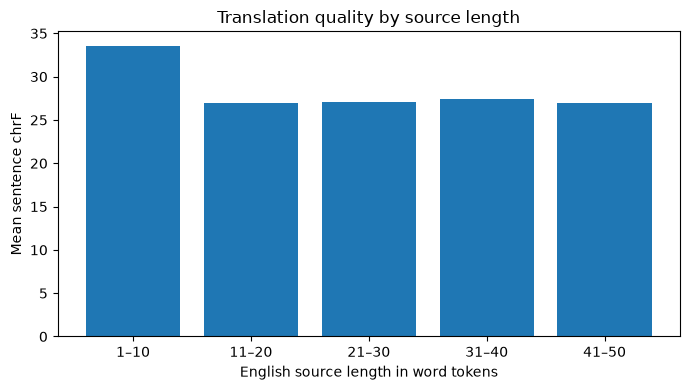

In [19]:
predictions = word_en_to_es["predictions"].copy()

predictions["length_group"] = pd.cut(
    predictions["source_length"],
    bins=[0, 10, 20, 30, 40, 50],
    labels=["1–10", "11–20", "21–30", "31–40", "41–50"],
    include_lowest=True,
)

length_results = (
    predictions
    .groupby("length_group", observed=False)
    .agg(
        pairs=("sentence_chrf", "size"),
        mean_chrf=("sentence_chrf", "mean"),
    )
    .reset_index()
)

length_results.to_csv(
    ARTIFACT_DIR / "length_analysis.csv",
    index=False,
)

display(length_results)

plt.figure(figsize=(7, 4))
plt.bar(
    length_results["length_group"].astype(str),
    length_results["mean_chrf"],
)
plt.xlabel("English source length in word tokens")
plt.ylabel("Mean sentence chrF")
plt.title("Translation quality by source length")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "chrf_by_source_length.png",
    dpi=200,
)
plt.show()

In [20]:
columns = [
    "source",
    "reference",
    "hypothesis",
    "source_length",
    "sentence_chrf",
]

print("Lowest sentence chrF")
display(
    predictions
    .sort_values("sentence_chrf")
    .head(5)[columns]
)

print("Highest sentence chrF")
display(
    predictions
    .sort_values("sentence_chrf", ascending=False)
    .head(5)[columns]
)

Lowest sentence chrF


,source,reference,hypothesis,source_length,sentence_chrf
29554,peru,perú,<unk>,1,1.000000e-14
951,"president,",señor presidente:,,2,1.000000e-14
9122,very good.,¡excelente!,.,3,1.000000e-14
12665,part two,ii parte,dos dos,2,1.000000e-14
11756,and,y,,1,1.000000e-14


Highest sentence chrF


,source,reference,hypothesis,source_length,sentence_chrf
16989,why not?,¿por qué no?,¿por qué no?,3,100.0
3097,written statements (rule 142),declaraciones por escrito (artículo 142 del re...,declaraciones por escrito (artículo 142 del re...,6,100.0
5836,(applause),(aplausos),(aplausos),3,100.0
16381,president-in-office of the council.,presidente en ejercicio del consejo.,presidente en ejercicio del consejo.,9,100.0
2303,in writing. - i voted for this report.,por escrito. - he votado a favor de este informe.,por escrito. - he votado a favor de este informe.,10,100.0
